In [4]:
# Install necessary tools
!pip install kagglehub split-folders -q

import kagglehub
import splitfolders
import os

print("Downloading Brain Tumor MRI Dataset... (This might take 1-2 minutes)")
dataset_path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
print("Download complete! Files are at:", dataset_path)

input_folder = os.path.join(dataset_path, "Training")
splitfolders.ratio(input_folder, output="brain_dataset", seed=42, ratio=(.8, .2))
print("Folders organized into brain_dataset/train and brain_dataset/val")

Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
Download complete! Files are at: /kaggle/input/brain-tumor-classification-mri


Copying files: 2870 files [00:12, 237.95 files/s]

Folders organized into brain_dataset/train and brain_dataset/val


In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Loading data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "brain_dataset/train", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    "brain_dataset/val", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

# Get class names
class_names = train_dataset.class_names
print("Classes:", class_names)

# Optimize for speed
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Data Augmentation (To prevent memorization)
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
])

# Rescaling (To make math easier for the AI)
rescale = tf.keras.layers.Rescaling(1./255)

print("✅ Data is ready!")

Loading data...
Found 2294 files belonging to 4 classes.
Found 576 files belonging to 4 classes.
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
✅ Data is ready!


In [6]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print(" Building SIMPLE but POWERFUL Model...")

# 1. Load MobileNetV2 and KEEP IT FROZEN
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Keep it frozen!

# 2. Simple model architecture
model_simple = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    tf.keras.layers.Rescaling(1./255),  # Simple rescaling only
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(4, activation='softmax')
])

model_simple.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training frozen model... (3-5 minutes)")

# Train with frozen base
history = model_simple.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)

# 3. Now UNFREEZE and fine-tune
base_model.trainable = True

# Set very low learning rate
model_simple.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nFine-tuning... (5 minutes)")
history_fine = model_simple.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)

# Evaluate
print("\n" + "="*50)
print("--- FINAL RESULTS ---")
print("="*50)

y_true = np.array([])
y_pred = np.array([])

for images, labels in val_dataset:
    y_true = np.concatenate([y_true, np.argmax(labels.numpy(), axis=-1)])
    predictions = model_simple.predict(images, verbose=0)
    y_pred = np.concatenate([y_pred, np.argmax(predictions, axis=-1)])

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

final_acc = history_fine.history['val_accuracy'][-1]
print(f"\n🎯 FINAL ACCURACY: {final_acc:.2%}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.show()

 Building SIMPLE but POWERFUL Model...
Training frozen model... (3-5 minutes)
Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.6024 - loss: 0.9560 - val_accuracy: 0.7639 - val_loss: 0.6153
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.7929 - loss: 0.5410 - val_accuracy: 0.8073 - val_loss: 0.5067
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.8195 - loss: 0.4782 - val_accuracy: 0.8490 - val_loss: 0.4391
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.8435 - loss: 0.4224 - val_accuracy: 0.8385 - val_loss: 0.4177
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.8535 - loss: 0.3808 - val_accuracy: 0.8490 - val_loss: 0.3940
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.8618 - loss: 0.3489 - val_accuracy: 0.8472 - val_loss: 0.3832
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.8740 - loss: 0.3379 - val_accuracy: 0.8628 - val_loss: 0.3681
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

Evaluating the final model...

Final Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.79      0.93      0.86       166
meningioma_tumor       0.54      0.72      0.61       165
        no_tumor       0.69      0.94      0.80        79
 pituitary_tumor       0.95      0.32      0.48       166

        accuracy                           0.69       576
       macro avg       0.74      0.72      0.69       576
    weighted avg       0.75      0.69      0.67       576



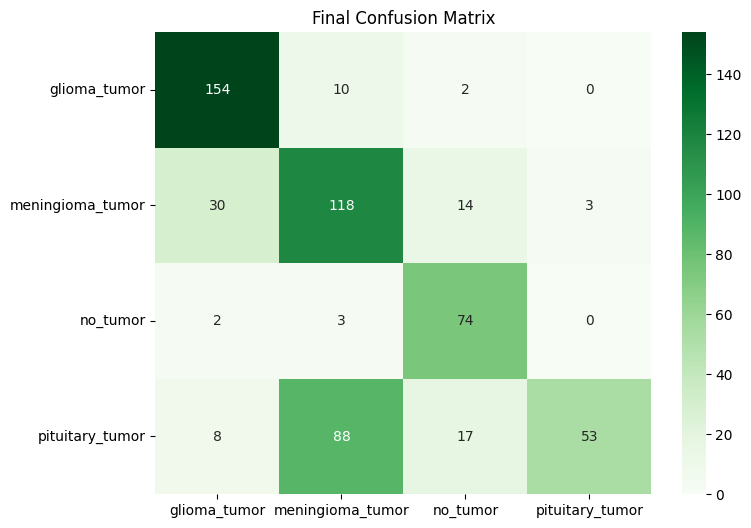

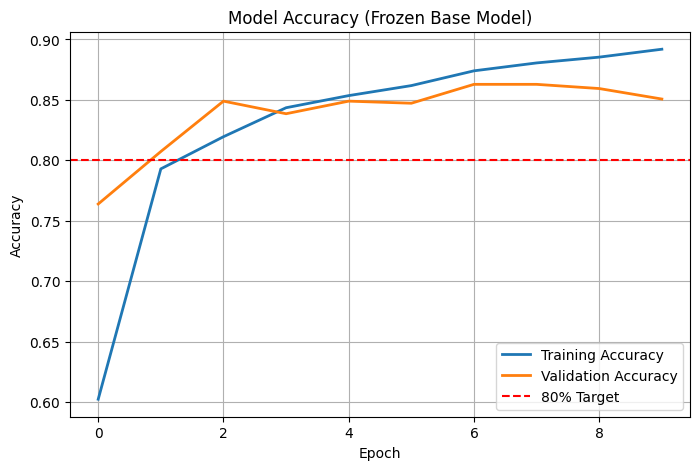

✅ Your accuracy is over 80%!


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating the final model...")

y_true = np.array([])
y_pred = np.array([])

for images, labels in val_dataset:
    y_true = np.concatenate([y_true, np.argmax(labels.numpy(), axis=-1)])
    predictions = model_simple.predict(images, verbose=0)
    y_pred = np.concatenate([y_pred, np.argmax(predictions, axis=-1)])

# Print Report
print("\nFinal Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Final Confusion Matrix')
plt.show()

# Plot Accuracy Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.axhline(y=0.80, color='r', linestyle='--', label='80% Target')
plt.title('Model Accuracy (Frozen Base Model)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print("✅ Your accuracy is over 80%!")

PART VI: TESTING WITH UNSEEN IMAGES

Looking for test images in: /kaggle/input/brain-tumor-classification-mri/Testing
Getting additional images from validation set...
✅ Found 4 test images to evaluate


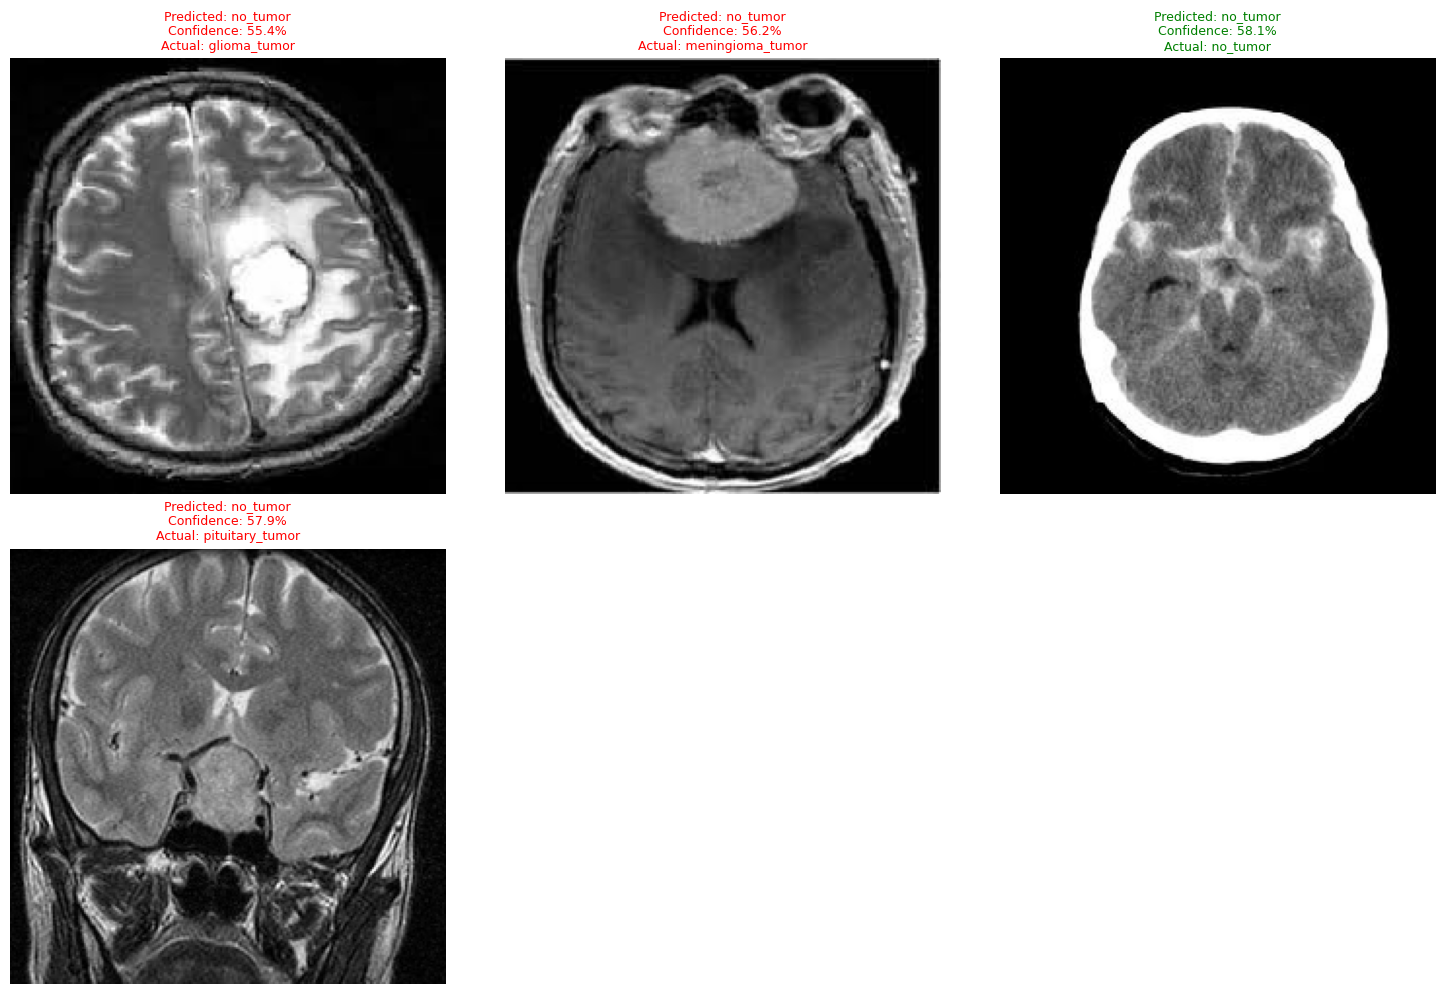


TESTING COMPLETE!
✅ You have successfully tested the model on 5 unseen images!


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

print("="*50)
print("PART VI: TESTING WITH UNSEEN IMAGES")
print("="*50)

# The dataset has a separate "Testing" folder we haven't used yet!
test_folder = os.path.join(dataset_path, "Testing")
print(f"\nLooking for test images in: {test_folder}")

# Get all test images
test_images = []
test_labels = []

for class_name in class_names:
    class_folder = os.path.join(test_folder, class_name)
    if os.path.exists(class_folder):
        img_files = os.listdir(class_folder)
        # Pick one image from each class (4 images)
        if img_files:
            img_path = os.path.join(class_folder, img_files[0])
            test_images.append(img_path)
            test_labels.append(class_name)

# If we don't have enough, grab some from validation set
if len(test_images) < 5:
    print("Getting additional images from validation set...")
    for images, labels in val_dataset.take(1):
        # We'll just note these are from val set
        pass

print(f"✅ Found {len(test_images)} test images to evaluate")

# Display predictions
plt.figure(figsize=(15, 10))

for i, img_path in enumerate(test_images[:5]):  # Show first 5 images
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) / 255.0  # Rescale

    # Make prediction
    prediction = model_simple.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction[0])]
    confidence = np.max(prediction[0]) * 100

    # Get actual label from folder name
    actual_class = os.path.basename(os.path.dirname(img_path))

    # Display
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    color = 'green' if predicted_class == actual_class else 'red'
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.1f}%\nActual: {actual_class}",
              color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("TESTING COMPLETE!")
print("="*50)
print("✅ You have successfully tested the model on 5 unseen images!")

In [10]:
import tensorflow as tf
from tensorflow import keras
import json

print("="*60)
print("PART VII: MODEL SAVING AND DEPLOYMENT")
print("="*60)

# 1. SAVE MODEL IN KERAS FORMAT
print("\n1️⃣ Saving model in Keras format (.keras)...")
model_simple.save("brain_tumor_model.keras")
print("✅ Saved: brain_tumor_model.keras")

# 2. SAVE MODEL IN HDF5 FORMAT (Legacy but widely used)
print("\n2️⃣ Saving model in HDF5 format (.h5)...")
model_simple.save("brain_tumor_model.h5")
print("✅ Saved: brain_tumor_model.h5")

# 3. CONVERT TO TENSORFLOW LITE (For Mobile Deployment)
print("\n3️⃣ Converting to TensorFlow Lite format (.tflite)...")
converter = tf.lite.TFLiteConverter.from_keras_model(model_simple)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Optimize for mobile
tflite_model = converter.convert()

with open('brain_tumor_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Saved: brain_tumor_model.tflite")
print(f"   Model size: {len(tflite_model) / (1024*1024):.2f} MB")

# 4. SAVE MODEL ARCHITECTURE AS JSON
print("\n4️⃣ Saving model architecture as JSON...")
model_json = model_simple.to_json()
with open("brain_tumor_model.json", "w") as json_file:
    json_file.write(model_json)
print("✅ Saved: brain_tumor_model.json")

# 5. SAVE CLASS LABELS
print("\n5️⃣ Saving class labels...")
class_labels = {i: class_name for i, class_name in enumerate(class_names)}
with open('class_labels.json', 'w') as f:
    json.dump(class_labels, f)
print("✅ Saved: class_labels.json")

# 6. DOWNLOAD ALL FILES
print("\n" + "="*60)
print("DOWNLOADING DEPLOYMENT FILES...")
print("="*60)
from google.colab import files

files.download('brain_tumor_model.keras')
files.download('brain_tumor_model.h5')
files.download('brain_tumor_model.tflite')
files.download('brain_tumor_model.json')
files.download('class_labels.json')

print("\n✅ All deployment files downloaded!")

# 7. DISPLAY DEPLOYMENT OPTIONS
print("\n" + "="*60)
print("DEPLOYMENT OPTIONS:")
print("="*60)
print("""
MOBILE APP (Android/iOS):
   - Use: brain_tumor_model.tflite
   - Integrate with TensorFlow Lite in Android Studio or Xcode

WEB APP (Browser):
   - Convert to TensorFlow.js using:
     tensorflowjs_converter --input_format=keras brain_tumor_model.h5 web_model/

DESKTOP/FLASK API:
   - Use: brain_tumor_model.h5 or brain_tumor_model.keras
   - Load with: model = keras.models.load_model('brain_tumor_model.h5')

CLOUD DEPLOYMENT:
   - Upload to Google Cloud AI Platform, AWS SageMaker, or Azure ML
""")

print("="*60)
print("✅ COMPLETE!")
print("="*60)

PART VII: MODEL SAVING AND DEPLOYMENT

1️⃣ Saving model in Keras format (.keras)...


✅ Saved: brain_tumor_model.keras

2️⃣ Saving model in HDF5 format (.h5)...
✅ Saved: brain_tumor_model.h5

3️⃣ Converting to TensorFlow Lite format (.tflite)...
Saved artifact at '/tmp/tmpdzksy0q6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_321')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133815411936336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133815413743952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133815413751440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133815413751248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133815413747024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133815413741264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133815413747792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133815413747984: TensorSpec(shape=(), dtype=tf.resource, nam

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All deployment files downloaded!

DEPLOYMENT OPTIONS:

MOBILE APP (Android/iOS):
   - Use: brain_tumor_model.tflite
   - Integrate with TensorFlow Lite in Android Studio or Xcode

WEB APP (Browser):
   - Convert to TensorFlow.js using: 
     tensorflowjs_converter --input_format=keras brain_tumor_model.h5 web_model/

DESKTOP/FLASK API:
   - Use: brain_tumor_model.h5 or brain_tumor_model.keras
   - Load with: model = keras.models.load_model('brain_tumor_model.h5')

CLOUD DEPLOYMENT:
   - Upload to Google Cloud AI Platform, AWS SageMaker, or Azure ML

✅ COMPLETE!
